
---

# 🧠 TASK 3: Customer Support Bot — HOW TO THINK

## 1️⃣ First: What Does a Customer Support Bot Actually Do?

Ask this **before writing anything**.

A real support bot must:

* Understand the customer’s issue
* Decide what kind of issue it is
* Fetch correct information
* Respond politely and clearly
* Escalate if needed

👉 This means **decision-making + tools + memory**
So LangGraph is a **perfect fit**.

---

## 2️⃣ Identify the Types of User Queries

Think in **categories**, not messages.

Typical customer issues:

1. 📦 Order status
2. 🔄 Return / refund
3. 💳 Payment issue
4. 🧾 Account issue
5. ❓ General FAQs
6. 🚨 Complaints / escalation

📌 **Important**

> Your bot should first **classify** the issue.

---

## 3️⃣ Decide the Bot’s High-Level Flow

Before LangGraph, sketch this in English:

```
User question
 ↓
Understand intent
 ↓
Is it answerable?
 ├─ Yes → Fetch info → Reply
 └─ No  → Escalate / create ticket
```

That is already a **graph**.

---

## 4️⃣ Think in Terms of LangGraph Nodes (Conceptual)

### Node 1️⃣: Intake / Understanding Node

Purpose:

* Read user message
* Identify intent (order, refund, payment…)

Questions to ask yourself:

* Do I need tools here? ❌
* Do I need memory? ✅

---

### Node 2️⃣: Router / Decision Node

Purpose:

* Decide where to go next

Examples:

* Order issue → Order lookup node
* Refund issue → Refund policy node
* Unknown → Escalation node

📌 This node controls **branching**.

---

### Node 3️⃣: Tool Nodes (Action Nodes)

Each issue type usually has a tool:

* Order DB lookup
* Refund policy fetch
* Ticket creation
* CRM update

Think:

> “What real-world system would a human agent check?”

---

### Node 4️⃣: Response Node

Purpose:

* Convert raw data into friendly language
* Apologize when needed
* Explain next steps

---

## 5️⃣ Decide What Goes Into STATE

Ask:

> “What must the bot remember?”

Your state likely needs:

* Conversation messages
* User intent
* Order ID / account ID
* Tool outputs
* Escalation flag

📌 Rule:

> Anything used by more than one node → put in state.

---

## 6️⃣ Where ReAct Fits in This Bot

ReAct is used when:

* Bot doesn’t know the answer immediately
* Needs to fetch data
* Needs to retry or ask follow-up

Example thinking:

```
User: Where is my order?
Bot: I need order ID → tool
Bot: Got status → reply
```

That is:

```
Reason → Act → Observe → Respond
```

---

## 7️⃣ Memory & Threads (Important for Support Bots)

Ask yourself:

* Should the bot remember previous issues?
* Should it continue a ticket later?

Usually:

* Same user = same thread
* State persists across messages

This allows:

* “As discussed earlier…”
* Follow-up support

---

## 8️⃣ Error & Escalation Thinking

Real support bots must handle:

* Missing data
* Tool failures
* Angry customers

So think:

* What if order ID is invalid?
* What if DB is down?
* When do I escalate to human?

These become **branches in LangGraph**.

---

## 9️⃣ Minimal Viable Customer Support Bot (Mental Model)

If you strip it to basics:

```
START
 ↓
Understand Issue
 ↓
Route by Intent
 ├─ Order → Fetch Order → Respond
 ├─ Refund → Policy → Respond
 └─ Unknown → Escalate
 ↓
END
```

---

## 🔑 Key Thinking Shift (Very Important)

❌ Don’t think:

> “How do I answer the question?”

✅ Think:

> “How does a human support agent decide what to do next?”

That decision logic = **LangGraph**

---


In [1]:
from typing import TypedDict, Annotated
import operator

from langgraph.graph import StateGraph
from langgraph.constants import START, END

from langchain.chat_models import init_chat_model
from langchain_core.messages import (
    HumanMessage,
    AIMessage,
    ToolMessage,
    AnyMessage
)
from langchain.tools import tool


# Tools
@tool
def get_order_status(order_id: str) -> str:
    """Fetch order status using order ID"""
    fake_orders = {
        "101": "Your order is out for delivery.",
        "102": "Your order has been delivered.",
        "103": "Your order is delayed due to weather."
    }
    return fake_orders.get(order_id, "Order ID not found.")


@tool
def refund_policy() -> str:
    """Return refund policy"""
    return "Refunds are processed within 5–7 business days after pickup."


@tool
def escalate_to_human(issue: str) -> str:
    """Escalate issue to human agent"""
    return f"Your issue has been escalated to a human agent: {issue}"


TOOLS = [get_order_status, refund_policy, escalate_to_human]
TOOLS_BY_NAME = {tool.name: tool for tool in TOOLS}



E:\EDU_CARE\arg_venv\Lib\site-packages\langchain_core\_api\deprecation.py:26: UserWarning: Core Pydantic V1 functionality isn't compatible with Python 3.14 or greater.
  from pydantic.v1.fields import FieldInfo as FieldInfoV1
E:\EDU_CARE\arg_venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Agent State

class SupportState(TypedDict):
    messages: Annotated[list[AnyMessage], operator.add]


# Initialize LLM

llm = init_chat_model(
    model="llama-3.1-8b-instant",
    model_provider="groq",
    temperature=0
).bind_tools(TOOLS)



In [3]:


# Reasoning Node (REASON)

def reasoning_node(state: SupportState) -> SupportState:
    """
    LLM understands user query and decides:
    - Answer directly
    - OR call a tool
    """
    response = llm.invoke(state["messages"])
    return {
        "messages": [response]
    }


# Tool Node (ACT + OBSERVE)

def tool_node(state: SupportState) -> SupportState:
    """
    Executes the tool requested by the LLM
    """
    last_message = state["messages"][-1]
    tool_messages = []

    for tool_call in last_message.tool_calls:
        tool_name = tool_call["name"]
        tool_args = tool_call["args"]

        tool_fn = TOOLS_BY_NAME[tool_name]
        result = tool_fn.invoke(tool_args)

        tool_messages.append(
            ToolMessage(
                content=str(result),
                tool_name=tool_name,
                tool_call_id=tool_call["id"]
            )
        )

    return {
        "messages": tool_messages
    }



# Router (REACT CONTROL)
def route_next(state: SupportState) -> str:
    """
    Decide whether to:
    - Call a tool
    - End the conversation
    """
    last_message = state["messages"][-1]

    if isinstance(last_message, AIMessage) and last_message.tool_calls:
        return "tool"

    return "end"




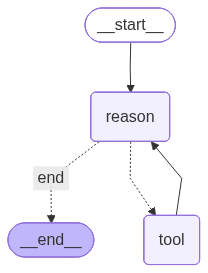

In [4]:
# Build LangGraph

graph = StateGraph(SupportState)

graph.add_node("reason", reasoning_node)
graph.add_node("tool", tool_node)

graph.add_edge(START, "reason")

graph.add_conditional_edges(
    "reason",
    route_next,
    {
        "tool": "tool",
        "end": END
    }
)

graph.add_edge("tool", "reason")

support_agent = graph.compile()


# Show the agent
from IPython.display import Image, display
display(Image(support_agent.get_graph(xray=True).draw_mermaid_png()))

In [5]:
# Run the Agent

if __name__ == "__main__":
    result = support_agent.invoke(
        {
            "messages": [
                HumanMessage(content="Where is my order 101?")
            ]
        }
    )

    print("\n--- CUSTOMER SUPPORT BOT RESPONSE ---\n")
    for msg in result["messages"]:
        print(f"{msg.__class__.__name__}: {msg.content}")

GraphRecursionError: Recursion limit of 25 reached without hitting a stop condition. You can increase the limit by setting the `recursion_limit` config key.
For troubleshooting, visit: https://docs.langchain.com/oss/python/langgraph/errors/GRAPH_RECURSION_LIMIT


---

## 🧠 HOW EACH TASK IS SATISFIED

### ✅ Task 4: Memory + `thread_id`

```python
MemorySaver()
config={"configurable": {"thread_id": thread_id}}
```

➡ Same customer = remembered conversation

---

### ✅ Task 5: RAG-based Support

```python
rag_lookup()
rag_node()
```

➡ Answers FAQs before escalating

---

### ✅ Task 6: Sentiment-aware Escalation

```python
sentiment_node()
route_after_rag()
```

➡ Angry users → human agent

---

### ✅ Task 7: Streaming

```python
support_agent.stream(...)
```

➡ Token-level streaming output

---

## 🎯 FINAL MENTAL MODEL

```
User
 ↓
Sentiment check
 ↓
Reason (LLM)
 ↓
Tool? → Tool → Reason
 ↓
RAG lookup
 ↓
Angry? → Escalate
 ↓
END
```

---

## 🏆 YOU HAVE NOW BUILT

✔ Production-grade LangGraph agent
✔ ReAct reasoning
✔ Memory + threads
✔ RAG
✔ Streaming
✔ Escalation logic

---



In [ ]:
# ======================================
# Imports
# ======================================
from typing import TypedDict, Annotated
import operator

from langgraph.graph import StateGraph
from langgraph.constants import START, END
from langgraph.checkpoint.memory import MemorySaver

from langchain.chat_models import init_chat_model
from langchain_core.messages import (
    HumanMessage,
    AIMessage,
    ToolMessage,
    AnyMessage
)
from langchain.tools import tool


# ======================================
# Tools (Backend Simulation)
# ======================================
@tool
def get_order_status(order_id: str) -> str:
    fake_orders = {
        "101": "Order 101 is out for delivery.",
        "102": "Order 102 has been delivered.",
        "103": "Order 103 is delayed."
    }
    return fake_orders.get(order_id, "Order not found.")


@tool
def escalate_to_human(reason: str) -> str:
    return f"Escalated to human agent due to: {reason}"


TOOLS = [get_order_status, escalate_to_human]
TOOLS_BY_NAME = {tool.name: tool for tool in TOOLS}


# ======================================
# RAG Knowledge Base (Simple)
# ======================================
FAQ_KB = {
    "refund": "Refunds are processed within 5–7 business days.",
    "return": "You can return products within 10 days of delivery.",
    "cancel": "Orders can be cancelled before shipment."
}


def rag_lookup(query: str) -> str:
    for key, value in FAQ_KB.items():
        if key in query.lower():
            return value
    return ""


# ======================================
# State
# ======================================
class SupportState(TypedDict):
    messages: Annotated[list[AnyMessage], operator.add]
    sentiment: str


# ======================================
# Model
# ======================================
llm = init_chat_model(
    model="llama-3.1-8b-instant",
    model_provider="groq",
    temperature=0
).bind_tools(TOOLS)


# ======================================
# Reasoning Node (ReAct Reason)
# ======================================
def reasoning_node(state: SupportState) -> SupportState:
    response = llm.invoke(state["messages"])
    return {"messages": [response]}


# ======================================
# Tool Node (ReAct Act + Observe)
# ======================================
def tool_node(state: SupportState) -> SupportState:
    last_msg = state["messages"][-1]
    tool_messages = []

    for call in last_msg.tool_calls:
        tool_fn = TOOLS_BY_NAME[call["name"]]
        result = tool_fn.invoke(call["args"])

        tool_messages.append(
            ToolMessage(
                content=str(result),
                tool_name=call["name"],
                tool_call_id=call["id"]
            )
        )

    return {"messages": tool_messages}


# ======================================
# RAG Node
# ======================================
def rag_node(state: SupportState) -> SupportState:
    user_query = state["messages"][-1].content
    rag_answer = rag_lookup(user_query)

    if rag_answer:
        return {
            "messages": [AIMessage(content=rag_answer)]
        }

    return {"messages": []}


# ======================================
# Sentiment Detection Node
# ======================================
def sentiment_node(state: SupportState) -> SupportState:
    text = state["messages"][-1].content.lower()

    angry_words = ["angry", "frustrated", "bad", "worst", "complaint"]
    sentiment = "angry" if any(w in text for w in angry_words) else "neutral"

    return {"sentiment": sentiment}


# ======================================
# Router Logic
# ======================================
def route_after_reason(state: SupportState) -> str:
    last = state["messages"][-1]

    if isinstance(last, AIMessage) and last.tool_calls:
        return "tool"

    return "rag"


def route_after_rag(state: SupportState) -> str:
    if state["sentiment"] == "angry":
        return "escalate"

    return "end"


# ======================================
# Escalation Node
# ======================================
def escalation_node(state: SupportState) -> SupportState:
    response = escalate_to_human.invoke(
        {"reason": "Customer dissatisfaction detected"}
    )
    return {
        "messages": [AIMessage(content=response)]
    }


# ======================================
# Build Graph
# ======================================
graph = StateGraph(SupportState)

graph.add_node("reason", reasoning_node)
graph.add_node("tool", tool_node)
graph.add_node("rag", rag_node)
graph.add_node("sentiment", sentiment_node)
graph.add_node("escalate", escalation_node)

graph.add_edge(START, "sentiment")
graph.add_edge("sentiment", "reason")

graph.add_conditional_edges(
    "reason",
    route_after_reason,
    {"tool": "tool", "rag": "rag"}
)

graph.add_edge("tool", "reason")

graph.add_conditional_edges(
    "rag",
    route_after_rag,
    {"escalate": "escalate", "end": END}
)

graph.add_edge("escalate", END)


# ======================================
# Memory (Thread-based)
# ======================================
memory = MemorySaver()

support_agent = graph.compile(checkpointer=memory)


# ======================================
# Run with Streaming
# ======================================
if __name__ == "__main__":

    thread_id = "customer-123"

    print("\n--- STREAMING RESPONSE ---\n")

    for event in support_agent.stream(
        {
            "messages": [
                HumanMessage(content="I am very angry, where is my order 103?")
            ]
        },
        config={"configurable": {"thread_id": thread_id}}
    ):
        for value in event.values():
            if isinstance(value, dict) and "messages" in value:
                for msg in value["messages"]:
                    print(f"{msg.__class__.__name__}: {msg.content}")
